#  Portfolio strategies

Python for finance and optimization

We consider an investment universe of 10 stocks corresponding to those having the highest market capitalization as
 of end 2018.

The Goal of this project is :

We consider an investment universe of 10 stocks corresponding to those having the highest market capitalization as
# Portfolio Optimization Comparison (2019)

This project compares the performance of three different ## portfolio #strategies over the year 2019, applied to the top 10 highest-market-cap stocks as of end-2018:

- **Equally-Weighted Portfolio (EWP)** – Daily rebalanced equal weights.
- **Markowitz Minimum-Variance Portfolio** – Optimized using the 2017-2018 empirical covariance matrix.
- **Equal Risk Contribution (ERC) Portfolio** – Risk-balanced allocation based on the 2017-2018 covariance matrix.

The analysis evaluates each portfolio in terms of **Sharpe ratio** and **maximum drawdown**, providing insights into their relative risk-adjusted returns.

In [1]:
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.optimize import minimize

In [2]:
data = pd.read_excel('sbf120_as_of_end_2018.xlsx', sheet_name = 'Data')

In [3]:
%%time

price_df_list = []
for i in tqdm(range(120)):
    price_data = data.iloc[:,3*i:3*i+2].copy()
    price_data.dropna(inplace=True)
    price_data.iloc[:,0] = pd.to_datetime(price_data.iloc[:,0], unit= 'D', origin= '1899-12-30')
    price_data.rename(columns = {price_data.columns[0] : 'Date', price_data.columns[1]: price_data.columns[0]}, inplace = True)
    price_data.set_index('Date', inplace = True)
    price_df_list.append(price_data)

agg_price_data = price_df_list[0]
for df in tqdm(price_df_list[1:]):
    agg_price_data = agg_price_data.join(df, how='outer', sort = True)

100%|███████████████████████████████████████████████████████████████████████████████| 119/119 [00:00<00:00, 298.37it/s]

Wall time: 912 ms


In [4]:

for ticker in agg_price_data.columns: #the loop can be avoided thanks to the function apply as seen in class (important for large dataframe)
    series = agg_price_data[ticker]
    first = series.first_valid_index()
    last = series.last_valid_index()
    series_real = series[(series.index >= first) & (series.index <= last)].fillna(method = 'bfill')
    agg_price_data[ticker][(agg_price_data[ticker].index >= first) & (agg_price_data[ticker].index <= last)] = series_real

In [5]:
df_mkt_cap_list = []
for i in tqdm(range(120)):
    mkt_cap_data = data.iloc[:,[3*i,3*i+2]].copy()
    mkt_cap_data.dropna(inplace = True)
    mkt_cap_data.iloc[:,0] = pd.to_datetime(mkt_cap_data.iloc[:,0], unit= 'D', origin= '1899-12-30')
    mkt_cap_data.rename(columns = {mkt_cap_data.columns[0] : 'Date', mkt_cap_data.columns[1]: mkt_cap_data.columns[0]}, inplace = True)
    mkt_cap_data.set_index('Date', inplace = True)
    df_mkt_cap_list.append(mkt_cap_data)

agg_mkt_cap_data = df_mkt_cap_list[0]
for df in tqdm(df_mkt_cap_list[1:]):
    agg_mkt_cap_data = agg_mkt_cap_data.join(df, how='outer', sort = True)

100%|███████████████████████████████████████████████████████████████████████████████| 119/119 [00:00<00:00, 387.41it/s]


We consider an investment universe of 10 stocks corresponding to those having the highest market capitalization as
of end 2018.


In [6]:
end_of_2018 = '2018-12-31'
Data_2018 = agg_mkt_cap_data[agg_mkt_cap_data.index == end_of_2018]

Now lets choose 10 stocks corresponding to those having the highest market capitalization

In [7]:
# Sort the data by market capitalization in descending order
Data_sorted = Data_2018.T.sort_values(by=end_of_2018, ascending=False)
Data_sorted

Date,2018-12-31
MC FP Equity,130414.5455
TTE FP Equity,124001.7374
OR FP Equity,112743.5012
SAN FP Equity,94825.2974
AIR FP Equity,65183.8473
...,...
MDM FP Equity,755.9920
VK FP Equity,744.4591
GNFT FP Equity,540.7377
TCH FP Equity,395.3960


In [8]:
# Get the top 10 stocks with the highest market capitalization as of the end of 2018
ten_highest_mktcap = Data_sorted.head(10)
ten_highest_mktcap = ten_highest_mktcap.T
ten_highest_mktcap = list(ten_highest_mktcap.columns)
ten_highest_mktcap

['MC FP Equity',
 'TTE FP Equity',
 'OR FP Equity',
 'SAN FP Equity',
 'AIR FP Equity',
 'KER FP Equity',
 'RMS FP Equity',
 'BNP FP Equity',
 'EL FP Equity',
 'AI FP Equity']

In [9]:
price_df_list = []
for i in tqdm(range(120)):
    price_data = data.iloc[:,3*i:3*i+2].copy()
    price_data.dropna(inplace=True)
    price_data.iloc[:,0] = pd.to_datetime(price_data.iloc[:,0], unit= 'D', origin= '1899-12-30')
    price_data.rename(columns = {price_data.columns[0] : 'Date', price_data.columns[1]: price_data.columns[0]}, inplace = True)
    price_data.set_index('Date', inplace = True)
    price_df_list.append(price_data)

agg_price_data = price_df_list[0]
for df in tqdm(price_df_list[1:]):
    agg_price_data = agg_price_data.join(df, how='outer', sort = True)
    
# we select the year 2019 for calculate the perfs
agg_price_of_2019 = agg_price_data[(agg_price_data.index > '31/12/2018')  & (agg_price_data.index <= '31/12/2019')]

100%|███████████████████████████████████████████████████████████████████████████████| 119/119 [00:00<00:00, 336.39it/s]
<ipython-input-9-eb1d36cbfe4f>:15: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  agg_price_of_2019 = agg_price_data[(agg_price_data.index > '31/12/2018')  & (agg_price_data.index <= '31/12/2019')]


In [10]:
agg_price_of_2019

,QDT FP Equity,DIM FP Equity,RUI FP Equity,OR FP Equity,DG FP Equity,ALD FP Equity,URW NA Equity,KORI FP Equity,TTE FP Equity,DSY FP Equity,...,ATO FP Equity,MDM FP Equity,AKE FP Equity,MERY FP Equity,RI FP Equity,RCO FP Equity,STM FP Equity,ATE FP Equity,WLN FP Equity,NXI FP Equity
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,23.80,85.90,47.76,199.60,71.44,10.25,132.62,27.9126,46.655,20.570,...,54.2785,16.89,74.38,12.07,141.20,97.0790,12.145,72.45,41.62,38.48
2019-01-03,24.60,83.30,46.72,197.20,71.20,10.15,133.30,28.0050,46.255,19.256,...,51.4050,17.07,73.66,12.12,138.95,94.0515,10.735,70.25,39.00,38.28
2019-01-04,24.08,86.05,47.96,200.00,72.58,10.71,138.12,28.5222,47.410,20.010,...,53.2954,16.50,77.86,12.43,141.10,98.1709,10.905,72.45,39.70,38.50
2019-01-07,24.80,85.85,48.66,197.45,72.22,10.81,137.32,29.0764,47.300,20.400,...,52.7359,17.48,78.16,12.44,138.65,97.0790,11.350,73.65,38.92,38.36
2019-01-08,25.76,87.80,49.38,198.65,73.14,11.00,141.66,29.5382,47.200,20.700,...,54.3087,19.05,80.82,12.78,138.70,98.9154,11.370,74.80,40.28,39.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,21.84,147.10,55.40,265.30,99.60,13.88,139.65,38.4237,49.355,29.600,...,75.1000,12.74,95.46,12.08,161.20,110.2000,24.230,112.60,64.25,44.16
2019-12-24,21.60,148.40,55.25,264.50,98.76,13.88,139.40,38.3498,49.475,29.660,...,75.8600,12.80,96.44,12.14,162.55,110.7000,24.280,112.00,63.80,44.26
2019-12-27,21.90,147.20,55.25,266.10,99.54,14.00,141.00,38.5530,49.290,29.490,...,74.7800,12.75,95.20,12.28,162.00,110.7000,24.340,113.50,63.70,44.70


In [11]:
# Highest Market Capitalization ten stocks DataFrame
agg_price_of_2019 = agg_price_of_2019[ten_highest_mktcap]
agg_price_of_2019

,MC FP Equity,TTE FP Equity,OR FP Equity,SAN FP Equity,AIR FP Equity,KER FP Equity,RMS FP Equity,BNP FP Equity,EL FP Equity,AI FP Equity
Date,,,,,,,,,,
2019-01-02,253.30,46.655,199.60,75.40,84.17,402.8,477.6,39.085,110.70,96.4545
2019-01-03,243.65,46.255,197.20,74.66,81.21,380.7,464.0,38.855,109.65,94.6818
2019-01-04,251.15,47.410,200.00,75.34,85.12,397.4,477.8,40.740,110.80,97.3182
2019-01-07,250.70,47.300,197.45,73.84,83.56,396.4,472.2,40.680,110.60,96.7727
2019-01-08,258.55,47.200,198.65,74.42,86.65,410.5,479.9,40.885,111.20,96.9091
...,...,...,...,...,...,...,...,...,...,...
2019-12-23,413.80,49.355,265.30,90.71,132.78,582.0,676.6,53.110,138.15,126.4500
2019-12-24,414.10,49.475,264.50,90.63,133.14,587.4,678.0,52.980,138.60,126.0000
2019-12-27,417.60,49.290,266.10,90.84,133.28,590.7,677.4,52.970,139.15,126.8500


In [12]:
# Calculate daily returns
returns = agg_price_of_2019.pct_change().dropna()

In [20]:
# WE define a class strategy :
class Strategy:

    def __init__(self, name, returns):
        self.name = name
        self.returns = returns
        self.pnl = np.c_[np.array([100000.]), 100000.*np.cumprod(1.+returns.to_numpy()).reshape(1,-1)].flatten()

    def volatility(self):
        return np.std(self.returns)*np.sqrt(252)

    def sharpe_ratio(self):
        return np.mean(self.returns)*np.sqrt(252)/np.std(self.returns)

    def max_dd(self):
        return 1. - np.min(np.flip(np.minimum.accumulate(np.flip(self.pnl)))/self.pnl)

    def max_dd_2(self):
        return np.max(1. - self.pnl/np.maximum.accumulate(self.pnl))

    def illustrate(self):
        fig, ax = plt.subplots(1, 1)
        ax.plot(self.returns.index, self.pnl[1:], 'b', label=self.name + ' (vol: %.2f, Sharpe: %.2f, MDD: %.2f)'%
                                                          (self.volatility(), self.sharpe_ratio(), self.max_dd()))
        ax.set_xlabel('Time')  
        ax.set_ylabel('PnL')
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_title(f'PnL of the strategy {self.name}')
        ax.grid(axis='x', linestyle='--')
        fig.tight_layout()
        fig.savefig(f'{self.name}.pdf')
        plt.show()

# 1. Equally-weighted portfolio

It simply consists in giving the same capital weight to each asset class in the investment universe. We buy all the available assets in equal quantities, regardless of the risk that each of the assets represents.
$$ w_i = 1/N $$
Où $w_i$ représente le poids de l’actif i dans le portefeuille et N représente le nombre d’actifs qui composent ce portefeuille

In [21]:
# we define the weights of the ptf
weights_equal = weights_eq = np.ones(len(ten_highest_mktcap)) / len(ten_highest_mktcap)

returns_equal = (returns * weights_equal).sum(axis=1)
strategy_equal = Strategy('Equal Weight', returns_equal)

Equal Weight:
Volatility: 0.14277285969670642
Sharpe Ratio: 2.1859283640403686
Maximum Drawdown: 0.07191270295659924


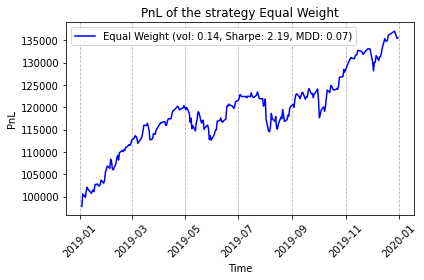

In [22]:
# Afficher les performances 
print('Equal Weight:')
print('Volatility:', strategy_equal.volatility())
print('Sharpe Ratio:', strategy_equal.sharpe_ratio())
print('Maximum Drawdown:', strategy_equal.max_dd())
strategy_equal.illustrate() # we choose 10^6 pour an initial wealth of 1M

# 2. Markowitz minimum-variance portfolio

MVP is the portfolio with the lowest risk. In Python, it can be solved with scipy.optimize.minimize, The minimum-variance portfolio (MVP) is the solution of the following problem:

$\begin{aligned} & \min _w w^T \sum_{\hat{R}} w \\ & \text { s.t. } \\ & \sum_i w_i=1 \text {, }\end{aligned}$


In [23]:
 ## the covariance matrix being computed over 2017-2018
agg_price_of_17_18 = agg_price_data[(agg_price_data.index > '31/12/2016')  & (agg_price_data.index <= '31/12/2018')]
agg_price_of_17_18 = agg_price_of_17_18[ten_highest_mktcap]
agg_price_of_17_18

<ipython-input-23-99ec6bcdd227>:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  agg_price_of_17_18 = agg_price_data[(agg_price_data.index > '31/12/2016')  & (agg_price_data.index <= '31/12/2018')]


,MC FP Equity,TTE FP Equity,OR FP Equity,SAN FP Equity,AIR FP Equity,KER FP Equity,RMS FP Equity,BNP FP Equity,EL FP Equity,AI FP Equity
Date,,,,,,,,,,
2017-01-02,181.80,48.800,173.45,77.84,62.82,201.39,390.830,60.350,107.30,87.1074
2017-01-03,179.70,48.930,170.15,78.30,63.50,199.06,389.144,61.920,106.30,87.3140
2017-01-04,178.10,48.905,169.85,78.30,63.40,196.41,386.021,62.800,105.40,87.2314
2017-01-05,176.95,48.930,170.30,78.27,64.60,194.83,384.732,62.220,105.40,87.2727
2017-01-06,179.25,48.770,170.25,76.69,65.14,197.95,387.409,62.490,105.80,87.6446
...,...,...,...,...,...,...,...,...,...,...
2018-12-21,253.45,46.045,200.70,75.68,83.10,396.10,475.400,39.500,110.35,97.8182
2018-12-24,245.15,45.230,197.65,74.24,81.63,387.00,463.500,38.790,109.65,97.0909
2018-12-27,247.15,45.350,195.60,73.76,82.10,385.50,469.300,38.545,108.80,95.3182


In [24]:
returns_2017_2018 = agg_price_of_17_18.pct_change().dropna()
covariance_matrix = returns_2017_2018.cov()

Optimization :
using a SLSQP (Sequential Least SQuares Programming) algorithm:

In [25]:
def minimum_variance(returns):
    def portf_variance(weights):
        cov = returns.cov()
        portf_var = np.sqrt(np.dot(weights.T, np.dot(cov, weights))) #
        return portf_var

    def weight_cons(weights):
        return np.sum(weights) - 1


    bounds_lim = [(0, 1) for x in range(len(returns.columns))] # change to (-1, 1) if you want to short
    initial_w = [1/len(returns.columns) for i in range(len(returns.columns))]
    constraint = {'type': 'eq', 'fun': weight_cons}

    optimal = minimize(fun=portf_variance,
                       x0=initial_w,
                       bounds=bounds_lim,
                       constraints=constraint,
                       method='SLSQP'
                       )

    return list(optimal['x'])

In [26]:
minimum_variance(returns_2017_2018)

[4.1554005506982044e-17,
 0.18155534137521412,
 0.10941682532620728,
 0.2144479865101635,
 0.0,
 0.0,
 0.23897692798448944,
 0.057982846307017374,
 0.12976120458873946,
 0.06785886790816884]

In [27]:
minimum_variance(returns_2017_2018)

[4.1554005506982044e-17,
 0.18155534137521412,
 0.10941682532620728,
 0.2144479865101635,
 0.0,
 0.0,
 0.23897692798448944,
 0.057982846307017374,
 0.12976120458873946,
 0.06785886790816884]

In [28]:
portfolio_returns_mv = (returns * minimum_variance(returns_2017_2018)).sum(axis=1)
Strategy.returns = portfolio_returns_mv
portfolio_returns_mv

Date
2019-01-03   -0.014601
2019-01-04    0.021211
2019-01-07   -0.009587
2019-01-08    0.006954
2019-01-09    0.005838
                ...   
2019-12-23    0.002542
2019-12-24    0.000456
2019-12-27    0.001230
2019-12-30   -0.011047
2019-12-31   -0.000593
Length: 254, dtype: float64

Markowitz Minimum Variance:
Sharpe Ratio: 1.839836792896665
Volatility: 0.127943530434318
Maximum Drawdown: 0.0635911360599507


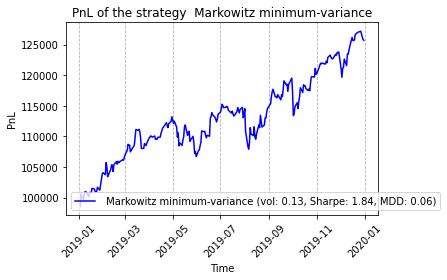

In [29]:
strategy_mv = Strategy(' Markowitz minimum-variance', portfolio_returns_mv)
# Afficher les performances de la stratégie Mv
print('Markowitz Minimum Variance:')
print('Sharpe Ratio:', strategy_mv.sharpe_ratio())
print('Volatility:', strategy_mv.volatility())
print('Maximum Drawdown:', strategy_mv.max_dd())
strategy_mv.illustrate()

### 3. ERC portfolio

This approach accounts for the interactions between different assets in a portfolio. The Equal Risk Contribution (ERC) allocation method calibrates asset weights so that each asset contributes equally to the overall portfolio risk. 

La contribution au risque :
$$
\forall i \quad C R_i=\omega_i \frac{\partial \sigma_{\mathrm{p}}}{\partial \omega_i}=\omega_i \frac{(\Omega \cdot \omega)_i}{\sigma_{\mathrm{p}}(\omega)}
$$

In this perspective, one approach is to solve the following optimization problem using a SLSQP (Sequential Least SQuares Programming) algorithm:
$$
\begin{aligned}
x^{\star}= & \arg \min f(x) \\
\text { u.c. } & \mathbf{1}^{\top} x=1 \text { and } \mathbf{0} \leq x \leq \mathbf{1}
\end{aligned}
$$
where:
$$
f(x)=\sum_{i=1}^n \sum_{j=1}^n\left(x_i(\Sigma x)_i-x_j(\Sigma x)_j\right)^2
$$
ref : Roncalli, On the properties of equally-weighted
risk contributions portfolios

In [30]:
def getERCWeights(cov, x0=None, options=None):
    # checking cov is pd
    if np.any(np.linalg.eigvals(cov) <= 0):
        return None

    n = cov.shape[0]

    # naive inverse weighting
    if x0 == None:
        diagInv = 1/np.sqrt(np.diag(cov))
        x0 = diagInv/diagInv.sum()

    def obj(x):
        riskCon = np.dot(cov, x)*x
        riskCon = np.reshape(riskCon, (len(x), 1))
        diffMat = riskCon - riskCon.T
        cost = np.linalg.norm(diffMat)**2
        return cost

    bounds_lim = [(0, 1) for i in range(n)]
    constraints = {'type': 'eq', 'fun': lambda x: sum(x)-1}

    optimal = minimize(obj, x0, method='SLSQP', bounds=bounds_lim,
                          constraints=constraints,)

    w = optimal.x
    return w #


In [31]:
getERCWeights(covariance_matrix)

array([0.08665366, 0.11549422, 0.11433038, 0.11503493, 0.07868983,
       0.06801732, 0.11469386, 0.09114227, 0.09905546, 0.11688808])

In [32]:
portfolio_returnsERC = (returns * getERCWeights(covariance_matrix)).sum(axis=1)
Strategy.returns = portfolio_returnsERC
portfolio_returnsERC

Date
2019-01-03   -0.020184
2019-01-04    0.027121
2019-01-07   -0.008097
2019-01-08    0.012429
2019-01-09    0.006831
                ...   
2019-12-23    0.002304
2019-12-24    0.000663
2019-12-27    0.002786
2019-12-30   -0.011255
2019-12-31    0.000507
Length: 254, dtype: float64

ERC:
Sharpe Ratio: 2.153863168642535
Volatility: 0.13793084737436048
Maximum Drawdown: 0.06861045743243244


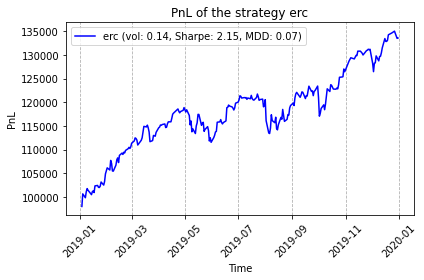

In [35]:
#third_strategy = Strategy("ERC_portfolio_strategy",portfolio_returns)
strategy_erc = Strategy('erc', portfolio_returnsERC)
# Afficher les performances de la stratégie à poids égaux
print('ERC:')
print('Sharpe Ratio:', strategy_erc.sharpe_ratio())
print('Volatility:', strategy_erc.volatility())
print('Maximum Drawdown:', strategy_erc.max_dd())
strategy_erc.illustrate()

## PLot the three PnL trajectories :

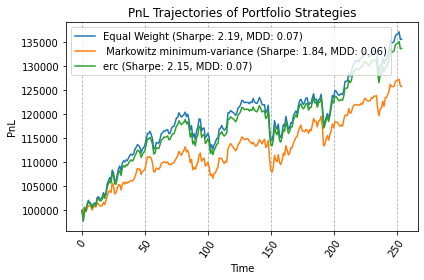

In [34]:
# Plot the PnL trajectories for the three strategies # we modifie in the class to choose the initial wealth of 1M
fig, ax = plt.subplots(1, 1)
ax.plot(strategy_equal.pnl, label=strategy_equal.name + f' (Sharpe: {strategy_equal.sharpe_ratio():.2f}, MDD: {strategy_equal.max_dd():.2f})')
ax.plot(strategy_mv.pnl, label=strategy_mv.name + f' (Sharpe: {strategy_mv.sharpe_ratio():.2f}, MDD: {strategy_mv.max_dd():.2f})')
ax.plot(strategy_erc.pnl, label=strategy_erc.name + f' (Sharpe: {strategy_erc.sharpe_ratio():.2f}, MDD: {strategy_erc.max_dd():.2f})')

ax.set_xlabel('Time')
ax.set_ylabel('PnL')
ax.legend()
ax.tick_params(axis='x', rotation=55)
ax.set_title('PnL Trajectories of Portfolio Strategies')
ax.grid(axis='x', linestyle='--')
fig.tight_layout()
plt.show()

we remark that ERC and EW performed the best while the  minimum variance performed the worst. this confirmed by the he high Sharpe ratios for both strategies 1 and 3

---